In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
%run load_data.py
%run build_dataset.py

In [3]:
conn = sqlite3.connect("uplift.db")
df = pd.read_sql("SELECT * FROM uplift_dataset",conn)
conn.close()

# Analysis 1: Checking Whether Treatment and Control Groups Are Comparable


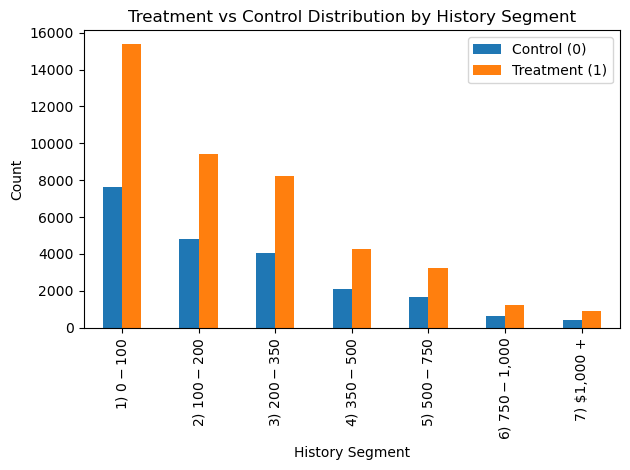

In [9]:
counts =  df.groupby(['treatment', 'history_segment']).size().unstack()
counts.T.plot(kind='bar')
plt.xlabel("History Segment")
plt.ylabel("Count")
plt.title("Treatment vs Control Distribution by History Segment")
plt.legend(["Control (0)", "Treatment (1)"])
plt.tight_layout()
plt.show()

*Interpreation of the graph:* The experiment assigned twice as many people to receive emails as those who received none. The assignment ratio was roughly 2:1 (Treatment:Control).

# Analysis 2: Measuring the Effect of Email on Sales

**Goal:** Determine whether sending the email (**Treatment**) actually increases sales on average.  

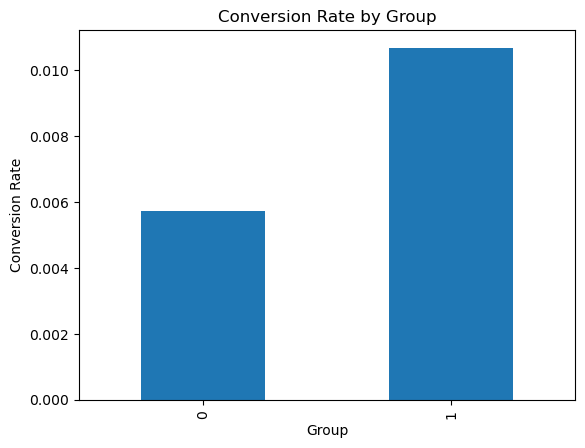

In [10]:
count_email = df.groupby('treatment')['target'].mean()
count_email.plot(kind ="bar")
plt.title("Conversion Rate by Group")
plt.ylabel("Conversion Rate")
plt.xlabel("Group")
plt.show()

*Interpreation of the graph :* The email campaign drives significant value. Sending the email nearly doubles the likelihood of a purchase compared to the control group.

# Analysis 3: Checking the distribution of users by zip code

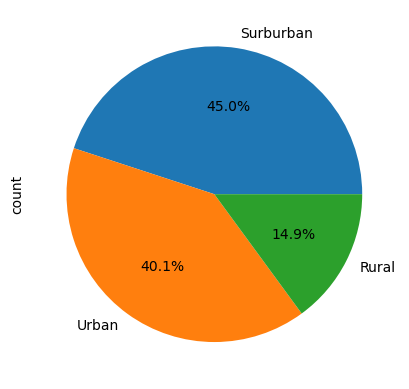

In [11]:
zip_count = df['zip_code'].value_counts()
zip_count.plot(kind='pie',autopct='%1.1f%%')
plt.show()

*Interpreation of the graph :* Customer base is predominantly Suburban and Urban. This indicates that our model will be most effective at predicting behaviors for city and suburb dwellers. We should be cautious when interpreting 'Rural' predictions, as the sample size is smaller